# Step-wise Run Evaluation

Evaluate step-by-step trend predictions logged under a PyMC model-selection run folder.

Folder layout:
```
<RUN_DIR>/<dataset_name>/<idx>_<label>/run_log.parquet
<RUN_DIR>/<dataset_name>/config.json      # points to the source .pkl (data_pkl)
```

Each `run_log.parquet` row is one step (step 0 = initial fit, step N = refinement N). The `trend`
column stores the JSON-encoded predicted trend for that step; `metrics` stores a JSON dict with AIC.

Per sample × step we compute R², RMSE, AIC, and CRPS.

## 1. Imports

In [1]:
import json
import pickle
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import norm
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)

## 2. Configure run paths

Point `RUN_DIR` at a timestamped run under `outputs/<expt>/`.  The dataset pickles are expected
alongside the repo root (same directory the experiments were launched from); override
`DATA_PKL_DIR` if that is not the case.

In [4]:
REPO_ROOT = Path('.').resolve()
RUN_DIR = REPO_ROOT / 'outputs' / 'claude_ts_runs_new' / 'ts_static_forced_dataset_ts_gravitational_chirp_50'
DATA_PKL_DIR = REPO_ROOT  # directory containing dataset_*.pkl files

assert RUN_DIR.exists(), f"RUN_DIR does not exist: {RUN_DIR}"
print(f"RUN_DIR     : {RUN_DIR}")
print(f"DATA_PKL_DIR: {DATA_PKL_DIR}")
print(f"Datasets in RUN_DIR: {[p.name for p in RUN_DIR.iterdir() if p.is_dir()]}")

RUN_DIR     : /Users/jain.k.5/Documents/GitHub/pymc_model_selection/outputs/claude_ts_runs_new/ts_static_forced_dataset_ts_gravitational_chirp_50
DATA_PKL_DIR: /Users/jain.k.5/Documents/GitHub/pymc_model_selection
Datasets in RUN_DIR: ['035_no anomalies', '032_no anomalies', '027_no anomalies', '020_no anomalies', '016_no anomalies', '043_no anomalies', '011_no anomalies', '044_no anomalies', '004_no anomalies', '003_no anomalies', '021_no anomalies', '026_no anomalies', '033_no anomalies', '034_no anomalies', '002_no anomalies', '005_no anomalies', '045_no anomalies', '010_no anomalies', '042_no anomalies', '017_no anomalies', '048_no anomalies', '008_no anomalies', '039_no anomalies', '009_no anomalies', '049_no anomalies', '038_no anomalies', '019_no anomalies', '028_no anomalies', '018_no anomalies', '029_no anomalies', '024_no anomalies', '023_no anomalies', '036_no anomalies', '031_no anomalies', '007_no anomalies', '000_no anomalies', '015_no anomalies', '040_no anomalies', '012

## 3. Discover samples in the run folder

Each dataset directory contains a `config.json` (with `data_pkl`) plus per-sample subfolders named
`<idx>_<label>` (e.g. `015_no anomalies`). The numeric prefix is the dataset sample index.

In [6]:
SAMPLE_DIR_RE = re.compile(r'^(\d+)_(.+)$')

def discover_samples(run_dir: Path) -> pd.DataFrame:
    """Return a DataFrame of (dataset, sample_idx, label, parquet_path, data_pkl).

    Supports two layouts:
      A) Nested:  run_dir/<dataset_name>/config.json + <idx>_<label>/run_log.parquet
      B) Flat:    run_dir/config.json + <idx>_<label>/run_log.parquet
    """
    rows = []

    def _collect(ds_name: str, ds_dir: Path, data_pkl: str):
        for sample_dir in sorted(ds_dir.iterdir()):
            if not sample_dir.is_dir():
                continue
            m = SAMPLE_DIR_RE.match(sample_dir.name)
            if m is None:
                continue
            parquet = sample_dir / 'run_log.parquet'
            if not parquet.exists():
                continue
            rows.append({
                'dataset': ds_name,
                'sample_idx': int(m.group(1)),
                'label': m.group(2),
                'parquet_path': parquet,
                'data_pkl': data_pkl,
            })

    # Check for flat layout: config.json directly in run_dir
    root_cfg = run_dir / 'config.json'
    if root_cfg.exists():
        cfg = json.loads(root_cfg.read_text())
        data_pkl = cfg.get('data_pkl')
        _collect(run_dir.name, run_dir, data_pkl)

    # Also check for nested layout: subdirectories with their own config.json
    for ds_dir in sorted(p for p in run_dir.iterdir() if p.is_dir()):
        cfg_path = ds_dir / 'config.json'
        if not cfg_path.exists():
            continue
        cfg = json.loads(cfg_path.read_text())
        data_pkl = cfg.get('data_pkl')
        _collect(ds_dir.name, ds_dir, data_pkl)

    return pd.DataFrame(rows)

samples_df = discover_samples(RUN_DIR)
print(f"Discovered {len(samples_df)} sample(s)")
samples_df.head()

Discovered 50 sample(s)


,dataset,sample_idx,label,parquet_path,data_pkl
0,ts_static_forced_dataset_ts_gravitational_chir...,0,no anomalies,/Users/jain.k.5/Documents/GitHub/pymc_model_se...,dataset_time_series/dataset_ts_gravitational_c...
1,ts_static_forced_dataset_ts_gravitational_chir...,1,no anomalies,/Users/jain.k.5/Documents/GitHub/pymc_model_se...,dataset_time_series/dataset_ts_gravitational_c...
2,ts_static_forced_dataset_ts_gravitational_chir...,2,no anomalies,/Users/jain.k.5/Documents/GitHub/pymc_model_se...,dataset_time_series/dataset_ts_gravitational_c...
3,ts_static_forced_dataset_ts_gravitational_chir...,3,no anomalies,/Users/jain.k.5/Documents/GitHub/pymc_model_se...,dataset_time_series/dataset_ts_gravitational_c...
4,ts_static_forced_dataset_ts_gravitational_chir...,4,no anomalies,/Users/jain.k.5/Documents/GitHub/pymc_model_se...,dataset_time_series/dataset_ts_gravitational_c...


## 4. Load ground-truth series from dataset pickles

The "ground truth" for a time series sample is the observed series stored in the source pickle
(`dataset[idx]['data']`). Metrics compare each step's predicted trend to this series.

In [7]:
_pkl_cache: dict[str, list] = {}

def load_pickle(pkl_name: str) -> list:
    if pkl_name not in _pkl_cache:
        pkl_path = DATA_PKL_DIR / pkl_name
        with open(pkl_path, 'rb') as f:
            _pkl_cache[pkl_name] = pickle.load(f)
    return _pkl_cache[pkl_name]

def get_actual(dataset_name: str, sample_idx: int, data_pkl: str) -> np.ndarray:
    dataset = load_pickle(data_pkl)
    return np.asarray(dataset[sample_idx]['data'].values, dtype=float)

# Attach ground-truth arrays (verify alignment for a couple of samples)
actuals: dict[tuple[str, int], np.ndarray] = {}
for row in samples_df.itertuples():
    actuals[(row.dataset, row.sample_idx)] = get_actual(row.dataset, row.sample_idx, row.data_pkl)

first_key = next(iter(actuals))
print(f"Example actual: key={first_key}, length={len(actuals[first_key])}, "
      f"first3={actuals[first_key][:3]}")

Example actual: key=('ts_static_forced_dataset_ts_gravitational_chirp_50', 0), length=600, first3=[0.16265864 0.05240801 0.86657773]


## 5. Load step-wise predicted trends

`run_log.parquet` stores `trend` and `metrics` as JSON strings. Parse them into numpy arrays and
floats. Some steps (e.g. a terminal `COMPLETE` step) may not have a fresh trend — they inherit the
previous step's values in the summary DataFrame.

In [8]:
def _safe_json(val):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return None
    if isinstance(val, (list, dict)):
        return val
    try:
        return json.loads(val)
    except (TypeError, ValueError, json.JSONDecodeError):
        return None

def load_run_log(parquet_path: Path) -> pd.DataFrame:
    df = pd.read_parquet(parquet_path)
    df['trend_arr'] = df['trend'].apply(
        lambda v: np.asarray(_safe_json(v), dtype=float) if _safe_json(v) is not None else None
    )
    df['metrics_dict'] = df['metrics'].apply(_safe_json)
    df['n_params_logged'] = df['metrics_dict'].apply(
        lambda d: int(d['n_params']) if isinstance(d, dict) and 'n_params' in d else np.nan
    )
    df['family'] = df['run_best_model_structure'].apply(
        lambda v: '_'.join(_safe_json(v)) if isinstance(_safe_json(v), list) else str(_safe_json(v))
    )
    return df[['step', 'family', 'trend_arr', 'n_params_logged']]

example = load_run_log(samples_df['parquet_path'].iloc[0])
example

,step,family,trend_arr,n_params_logged
0,0,periodic,"[-0.33986640786502786, -0.30447244399363266, -...",4
1,1,periodic,"[-0.08251760334890813, 0.04792380568687624, 0....",4
2,2,periodic,"[-0.327484937249603, -0.2934148418528073, -0.1...",4
3,3,periodic,"[-0.23054235148925067, -0.20499276872702954, -...",4
4,4,periodic,"[-0.03511935846482824, -0.08603569617635705, -...",6
5,5,periodic,"[8.866086238909588e-05, 8.866086247829536e-05,...",3


## 6. Define evaluation metrics

* **R²** — coefficient of determination of predicted trend vs actual series.
* **RMSE** — root mean squared error of predicted trend vs actual series.
* **AIC** — recomputed from the residual RSS via the usual Gaussian-likelihood formula
  (`AIC = 2k + n·log(RSS/n) + n(1 + log(2π))`). We also carry the AIC logged by the pipeline
  (`aic_logged`) for direct comparison.

* **CRPS** — Continuous Ranked Probability Score under a Gaussian predictive N(ŷ, σ̂) where  Lower is better; rewards both accuracy and calibrated uncertainty.
  σ̂ = RMSE of residuals (MLE plug-in). Uses the Gneiting & Raftery (2007) closed form.

In [9]:
def _align(y_true: np.ndarray, y_pred: np.ndarray) -> tuple[np.ndarray, np.ndarray] | None:
    if y_pred is None:
        return None
    n = min(len(y_true), len(y_pred))
    if n == 0:
        return None
    return y_true[:n], y_pred[:n]

def compute_r2(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    pair = _align(y_true, y_pred)
    if pair is None:
        return np.nan
    return float(r2_score(pair[0], pair[1]))

def compute_rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    pair = _align(y_true, y_pred)
    if pair is None:
        return np.nan
    return float(np.sqrt(mean_squared_error(pair[0], pair[1])))

def compute_aic(y_true: np.ndarray, y_pred: np.ndarray, num_params: int) -> float:
    """Gaussian-likelihood AIC recomputed from residuals."""
    pair = _align(y_true, y_pred)
    if pair is None or not np.isfinite(num_params):
        return np.nan
    resid = pair[0] - pair[1]
    n = len(resid)
    rss = float(np.sum(resid ** 2))
    if rss <= 0 or n == 0:
        return np.nan
    # AIC for Gaussian: 2k + n*log(RSS/n) + n*(1 + log(2*pi))
    return 2.0 * num_params + n * np.log(rss / n) + n * (1.0 + np.log(2.0 * np.pi))

def compute_crps(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Mean CRPS under Gaussian predictive N(ŷ_i, σ̂) with σ̂ = residual RMSE.

    Closed-form (Gneiting & Raftery 2007):
        CRPS_i = σ [ z_i (2Φ(z_i) - 1) + 2φ(z_i) - 1/√π ]
    where z_i = (y_i - ŷ_i) / σ.
    """
    pair = _align(y_true, y_pred)
    if pair is None:
        return np.nan
    resid = pair[0] - pair[1]
    sigma = float(np.sqrt(np.mean(resid ** 2)))  # RMSE as plug-in σ
    if sigma <= 0:
        return np.nan
    z = resid / sigma
    crps_pts = sigma * (z * (2.0 * norm.cdf(z) - 1.0) + 2.0 * norm.pdf(z) - 1.0 / np.sqrt(np.pi))
    return float(np.mean(crps_pts))

## 7. Compute per-step metrics for every sample

In [11]:
records: list[dict] = []
for row in samples_df.itertuples():
    try:
        y_true = actuals[(row.dataset, row.sample_idx)]
        log_df = load_run_log(row.parquet_path)
        for _, r in log_df.iterrows():
            trend = r['trend_arr']
            n_params = r['n_params_logged']
            rec = {
                'dataset': row.dataset,
                'sample_idx': row.sample_idx,
                'label': row.label,
                'step': int(r['step']),
                'family': r['family'],
                'n_params': None if pd.isna(n_params) else int(n_params),
                'r2': compute_r2(y_true, trend),
                'rmse': compute_rmse(y_true, trend),
                'aic': compute_aic(
                    y_true, trend, int(n_params) if not pd.isna(n_params) else 0
                ),
                'crps': compute_crps(y_true, trend),
            }
            records.append(rec)
    except:
        print(f"Error processing sample {row.dataset} idx={row.sample_idx}: {row.parquet_path}")
eval_df = pd.DataFrame(records)
print(f"Eval table: {len(eval_df)} rows (samples × steps)")
eval_df.head(10)

Eval table: 174 rows (samples × steps)


,dataset,sample_idx,label,step,family,n_params,r2,rmse,aic,crps
0,ts_static_forced_dataset_ts_gravitational_chir...,0,no anomalies,0,periodic,4,5.557804e-02,1.102579,1827.908993,0.646720
1,ts_static_forced_dataset_ts_gravitational_chir...,0,no anomalies,1,periodic,4,4.844012e-02,1.106738,1832.426730,0.649666
2,ts_static_forced_dataset_ts_gravitational_chir...,0,no anomalies,2,periodic,4,5.506141e-02,1.102881,1828.237120,0.647198
3,ts_static_forced_dataset_ts_gravitational_chir...,0,no anomalies,3,periodic,4,4.197198e-02,1.110493,1836.491369,0.653015
4,ts_static_forced_dataset_ts_gravitational_chir...,0,no anomalies,4,periodic,6,5.427417e-02,1.103340,1832.736780,0.649083
5,ts_static_forced_dataset_ts_gravitational_chir...,0,no anomalies,5,periodic,3,4.982681e-13,1.134558,1860.218324,0.668576
6,ts_static_forced_dataset_ts_gravitational_chir...,1,no anomalies,0,warped_periodic,5,9.846904e-01,0.134818,-691.866570,0.075922
7,ts_static_forced_dataset_ts_gravitational_chir...,1,no anomalies,1,warped_periodic,5,NaN,NaN,NaN,NaN
8,ts_static_forced_dataset_ts_gravitational_chir...,2,no anomalies,0,rbf,3,1.310063e-14,0.850690,1514.676677,0.500690
9,ts_static_forced_dataset_ts_gravitational_chir...,2,no anomalies,1,warped_periodic,5,7.621532e-03,0.847442,1514.086242,0.498740


## 8. Aggregate into a single sorted table

In [12]:
eval_df = eval_df.sort_values(['dataset', 'sample_idx', 'step']).reset_index(drop=True)
eval_df = eval_df.dropna()

## 9. Summary statistics

In [13]:
metric_cols = ['r2', 'rmse', 'aic', 'crps']

by_step = eval_df.groupby('step')[metric_cols].agg(['mean', 'median', 'std']).round(3)
print('=== Metrics aggregated by step (across all samples) ===')
display(by_step)

=== Metrics aggregated by step (across all samples) ===


r2                 rmse                    aic                      crps              
       mean median    std   mean median    std     mean   median       std   mean median    std
step                                                                                           
0     0.670  0.976  0.433  0.311  0.131  0.335 -284.011 -723.002  1142.231  0.179  0.074  0.197
1     0.359  0.128  0.418  0.507  0.413  0.385  401.902  648.837  1238.208  0.293  0.235  0.227
2     0.311  0.107  0.376  0.548  0.432  0.359  627.656  704.272  1076.651  0.316  0.246  0.212
3     0.389  0.217  0.372  0.495  0.371  0.349  503.371  521.541  1048.582  0.284  0.206  0.204
4     0.367  0.172  0.400  0.508  0.387  0.383  438.299  563.710  1207.449  0.292  0.214  0.224
5     0.377  0.177  0.389  0.528  0.426  0.393  488.091  690.931  1214.221  0.304  0.238  0.230

In [14]:
# metric_cols = ['r2', 'rmse', 'aic', 'crps']
metric_cols = ['r2']

by_sample = eval_df.groupby('sample_idx')[metric_cols].agg(['max']).round(3)
print('=== Metrics aggregated by sample (across all samples) ===')
display(by_sample)

=== Metrics aggregated by sample (across all samples) ===


,r2
,max
sample_idx,
0,0.056
1,0.985
2,0.973
3,0.980
4,0.982
5,0.982
6,0.986
7,0.980


In [15]:
by_sample[by_sample['r2']['max'] < 0.7]

,r2
,max
sample_idx,
0,0.056
15,0.170
18,0.216
25,0.103
28,0.276
34,0.107
40,0.115
42,0.096


## 10. Visualize metric evolution across steps

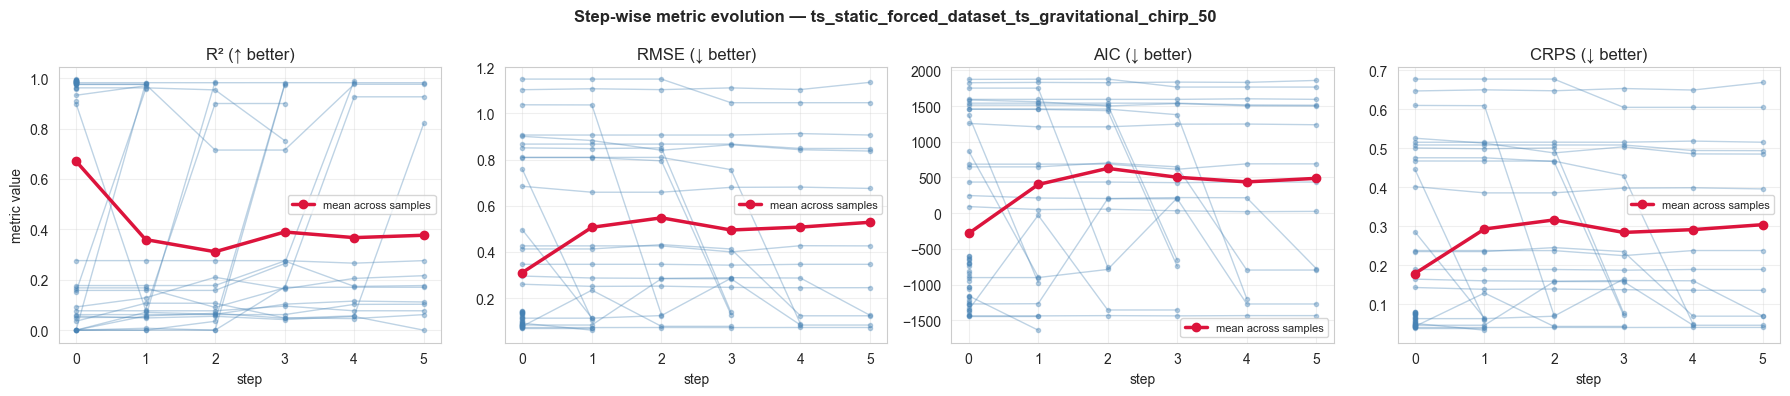

In [16]:
plot_metrics = [
    ('r2',             'R²',               True),
    ('rmse',           'RMSE',             False),
    ('aic',            'AIC',              False),
    ('crps',           'CRPS',             False),
]

fig, axes = plt.subplots(1, len(plot_metrics), figsize=(4.5 * len(plot_metrics), 4), sharex=True)
for ax, (col, title, higher_better) in zip(axes, plot_metrics):
    for (ds, idx), g in eval_df.groupby(['dataset', 'sample_idx']):
        ax.plot(g['step'], g[col], color='steelblue', alpha=0.35, linewidth=1.0,
                marker='o', markersize=3)
    mean_line = eval_df.groupby('step')[col].mean()
    ax.plot(mean_line.index, mean_line.values, color='crimson', linewidth=2.5,
            marker='o', label='mean across samples')
    direction = '↑' if higher_better else '↓'
    ax.set_title(f'{title} ({direction} better)')
    ax.set_xlabel('step')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)
axes[0].set_ylabel('metric value')
fig.suptitle(f'Step-wise metric evolution — {RUN_DIR.name}', fontweight='bold')
plt.tight_layout()
plt.show()

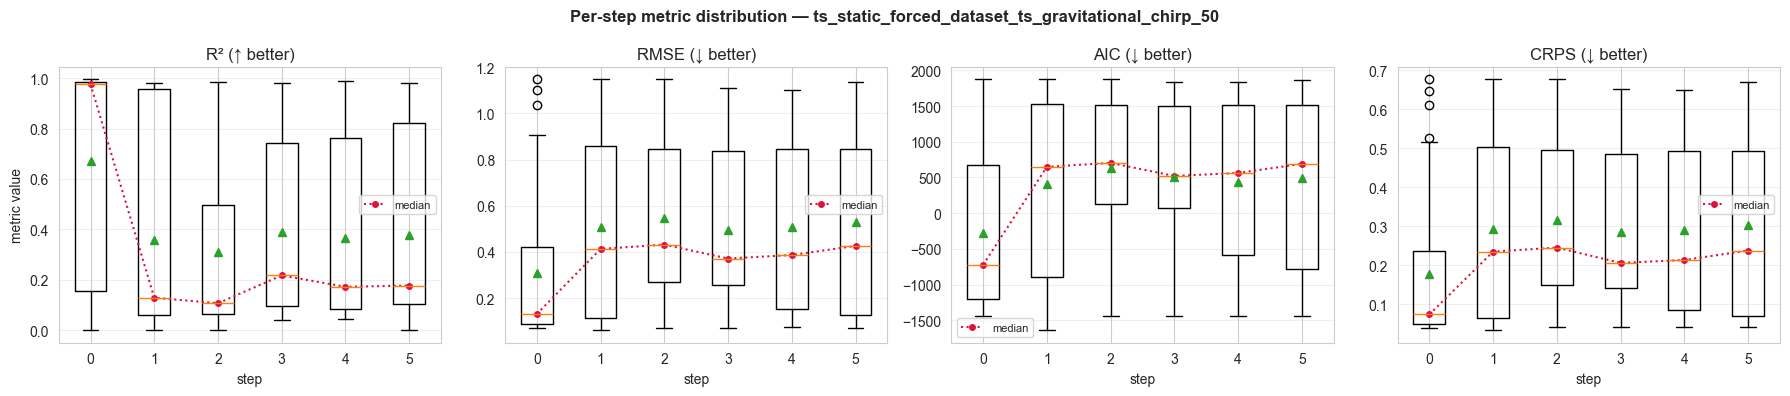

In [17]:
# Box-plot distribution of each metric at each step across samples.
fig, axes = plt.subplots(1, len(plot_metrics), figsize=(4.5 * len(plot_metrics), 4))
for ax, (col, title, higher_better) in zip(axes, plot_metrics):
    steps_sorted = sorted(eval_df['step'].unique())
    data_by_step = [
        eval_df.loc[eval_df['step'] == s, col].dropna().values
        for s in steps_sorted
    ]
    positions = np.arange(1, len(steps_sorted) + 1)
    ax.boxplot(data_by_step, tick_labels=[str(s) for s in steps_sorted], showmeans=True)
    medians = [np.median(d) if len(d) else np.nan for d in data_by_step]
    ax.plot(positions, medians, linestyle=':', color='crimson', linewidth=1.5,
            marker='o', markersize=4, label='median')
    direction = '↑' if higher_better else '↓'
    ax.set_title(f'{title} ({direction} better)')
    ax.set_xlabel('step')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(loc='best', fontsize=8)
axes[0].set_ylabel('metric value')
fig.suptitle(f'Per-step metric distribution — {RUN_DIR.name}', fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Per-step fit plots for a chosen sample

Set `INSPECT_DATASET` and `INSPECT_SAMPLE_IDX` to the sample you want to inspect. One subplot is
produced per step, overlaying the predicted trend on the ground-truth series.

In [47]:
index = 5

In [48]:
# Sample to inspect — change these to pick any sample discovered above.
INSPECT_DATASET = samples_df['dataset'].iloc[index]
INSPECT_SAMPLE_IDX = int(samples_df['sample_idx'].iloc[index])

sample_steps = (
    eval_df[(eval_df['dataset'] == INSPECT_DATASET)
            & (eval_df['sample_idx'] == INSPECT_SAMPLE_IDX)]
    .sort_values('step')
    .reset_index(drop=True)
)
assert not sample_steps.empty, f"No steps found for {INSPECT_DATASET}/{INSPECT_SAMPLE_IDX}"
print(f"Inspecting {INSPECT_DATASET}/{INSPECT_SAMPLE_IDX:03d} — {len(sample_steps)} step(s)")
sample_steps[['step', 'family', 'r2', 'rmse', 'aic', 'crps']]

Inspecting ts_static_forced_dataset_ts_gravitational_chirp_50/005 — 1 step(s)


,step,family,r2,rmse,aic,crps
0,0,warped_periodic,0.982409,0.089696,-1180.868759,0.050551


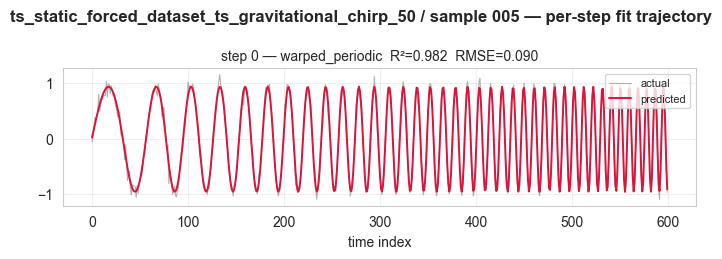

In [49]:
def _trend_for_sample(dataset: str, sample_idx: int, step: int) -> np.ndarray | None:
    row = samples_df[(samples_df['dataset'] == dataset) & (samples_df['sample_idx'] == sample_idx)]
    if row.empty:
        return None
    log_df = load_run_log(row['parquet_path'].iloc[0])
    match = log_df[log_df['step'] == step]
    if match.empty:
        return None
    return match['trend_arr'].iloc[0]

y_true = actuals[(INSPECT_DATASET, INSPECT_SAMPLE_IDX)]
n_steps = len(sample_steps)
ncols = 2 if n_steps > 1 else 1
nrows = int(np.ceil(n_steps / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 2.6 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).flatten()

for ax, (_, rec) in zip(axes, sample_steps.iterrows()):
    y_pred = _trend_for_sample(INSPECT_DATASET, INSPECT_SAMPLE_IDX, int(rec['step']))
    ax.plot(y_true, color='grey', alpha=0.6, linewidth=0.8, label='actual')
    if y_pred is not None:
        ax.plot(y_pred, color='crimson', linewidth=1.4, label='predicted')
    ax.set_title(
        f"step {int(rec['step'])} — {rec['family']}  "
        f"R²={rec['r2']:.3f}  RMSE={rec['rmse']:.3f}",
        fontsize=10,
    )
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

# Hide any unused axes
for ax in axes[n_steps:]:
    ax.set_visible(False)

for ax in axes[-ncols:]:
    ax.set_xlabel('time index')
fig.suptitle(
    f'{INSPECT_DATASET} / sample {INSPECT_SAMPLE_IDX:03d} — per-step fit trajectory',
    fontweight='bold',
)
plt.tight_layout()
plt.show()

## 12. Export evaluation table

In [29]:
out_parquet = RUN_DIR / 'evaluation_results.parquet'
out_csv = RUN_DIR / 'evaluation_results.csv'
eval_df.to_parquet(out_parquet, index=False)
eval_df.to_csv(out_csv, index=False)
print(f"Wrote: {out_parquet}")
print(f"Wrote: {out_csv}")

Wrote: /Users/jain.k.5/Documents/GitHub/pymc_model_selection/outputs/ts_static_forced/20260423_185203/evaluation_results.parquet
Wrote: /Users/jain.k.5/Documents/GitHub/pymc_model_selection/outputs/ts_static_forced/20260423_185203/evaluation_results.csv


crps column present: 3 / 3 non-null values
 step          family       r2     rmse          aic     crps
    0 linear_periodic 0.109767 0.397433   605.450321 0.217164
    1 warped_periodic 0.086833 0.402519   620.711739 0.221435
    2        periodic 0.953888 0.090452 -1172.795320 0.051372


In [ ]:
python experiments.py     --domain time-series     --data-pkl dataset_time_series/dataset_ts_medium_110.pkl      --dataset-idx "0:110"     --max-steps 5     --verbosity 1     --model.id "azure/gpt-5.4-mini"     --model.call-timeout 300     --toolkit.mode generate_only     --toolkit.code-gen-model "azure/gpt-5.4-mini"     --toolkit.force-tool-call     --parallel.nproc 4 --parallel.nthread 0     --parallel.max-rpm 120     --output.expt ts_genonly_forced